In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
import itertools
from implicit.als import AlternatingLeastSquares
from implicit.evaluation import ndcg_at_k, precision_at_k


%matplotlib inline
sns.set(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (7, 4)

* importing libraries and configures default plotting styles.

In [2]:
PATH = "C:\\Users\\ahmad\\deep learning project\\ml-25m\\ml-25m"

ratings = pd.read_csv(
    f"{PATH}/ratings.csv",
    dtype={"userId": "int32", "movieId": "int32", "rating": "float32", "timestamp": "int64"}
)

movies  = pd.read_csv(f"{PATH}/movies.csv")
tags    = pd.read_csv(f"{PATH}/tags.csv")

* Defines the file path and loads the ratings.csv, movies.csv, and tags.csv datasets. It optimizes memory by strictly defining datatypes (e.g., int32, float32) during the read_csv process.

In [3]:
print("Duplicate rows:", ratings.duplicated().sum())
print("Missing values per column:\n", ratings.isna().sum())
print("Rating range:", ratings.rating.min(), "–", ratings.rating.max())

Duplicate rows: 0
Missing values per column:
 userId       0
movieId      0
rating       0
timestamp    0
dtype: int64
Rating range: 0.5 – 5.0


In [4]:
ratings["datetime"] = pd.to_datetime(ratings["timestamp"], unit="s")
ratings = ratings.drop(columns=["timestamp"])

* Converts the raw Unix timestamp column into a readable Pandas datetime object, which is necessary for future time-based filtering, and drops the old column.

In [5]:
min_interactions = 5

user_counts = ratings['userId'].value_counts()
movie_counts = ratings['movieId'].value_counts()

valid_users = user_counts[user_counts >= min_interactions].index
valid_movies = movie_counts[movie_counts >= min_interactions].index

ratings = ratings[ratings['userId'].isin(valid_users) & ratings['movieId'].isin(valid_movies)]
print(f"Filtered Dataset: {len(ratings):,} interactions remaining.")

Filtered Dataset: 24,945,870 interactions remaining.


* Addresses the "Cold Start" problem and extreme data sparsity.
* It filters the dataset to include only users and movies that have a minimum of 5 interactions, significantly reducing noise.

In [6]:
OUT_PATH = "C:\\Users\\ahmad\\deep learning project\\outputs"

ratings.to_parquet(f"{OUT_PATH}/cleaned_ratings.parquet", index=False)
movies.to_parquet(f"{OUT_PATH}/cleaned_movies.parquet", index=False)
tags.to_parquet(f"{OUT_PATH}/cleaned_tags.parquet", index=False)

print("Cleaned files written to:", OUT_PATH)

Cleaned files written to: C:\Users\ahmad\deep learning project\outputs


* Saves the cleaned and filtered datasets as .parquet files. Parquet is a columnar storage format that is much faster to read and write compared to standard CSV files.

In [7]:
n_users   = ratings["userId"].nunique()
n_movies  = ratings["movieId"].nunique()
n_ratings = len(ratings)

print(f"Users   : {n_users:,}")
print(f"Movies  : {n_movies:,}")
print(f"Ratings : {n_ratings:,}")

Users   : 162,541
Movies  : 32,720
Ratings : 24,945,870


In [8]:
print(f"Mean rating : {ratings.rating.mean():.3f} ± {ratings.rating.std():.3f}")
print(f"Sparsity    : {(1 - n_ratings/(n_users*n_movies))*100:.2f}%")

Mean rating : 3.535 ± 1.060
Sparsity    : 99.53%


* Prints high-level summary statistics of the cleaned data, including the number of unique users (162,541), unique movies (32,720), the mean rating, and the calculated sparsity percentage (99.53%).

In [9]:
FIGURES_PATH = "C:\\Users\\ahmad\\deep learning project\\figures"

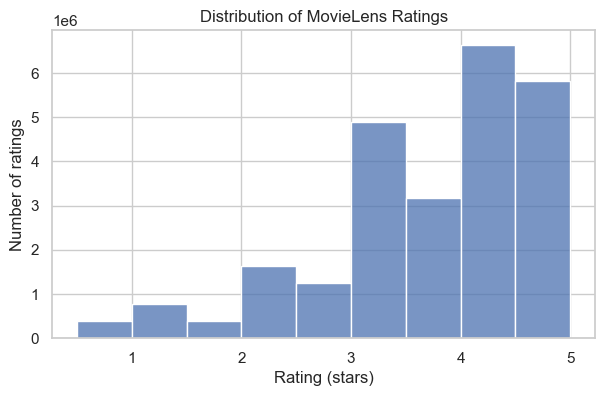

In [11]:
# Rating histogram
sns.histplot(ratings.rating, bins=np.arange(0.5,5.5,0.5), kde=False, color="#4C72B0")
plt.title("Distribution of MovieLens Ratings")
plt.xlabel("Rating (stars)")
plt.ylabel("Number of ratings")
plt.xticks([1,2,3,4,5])
plt.savefig(f"{FIGURES_PATH}/rating_histogram.png", dpi=300, bbox_inches="tight")
plt.show()

C:\Users\ahmad\AppData\Local\Temp\ipykernel_23276\2025508347.py:7: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  plt.savefig(f"{FIGURES_PATH}/user_activity.png", dpi=300, bbox_inches="tight")
C:\Users\ahmad\anaconda3\envs\recsys_gpu\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


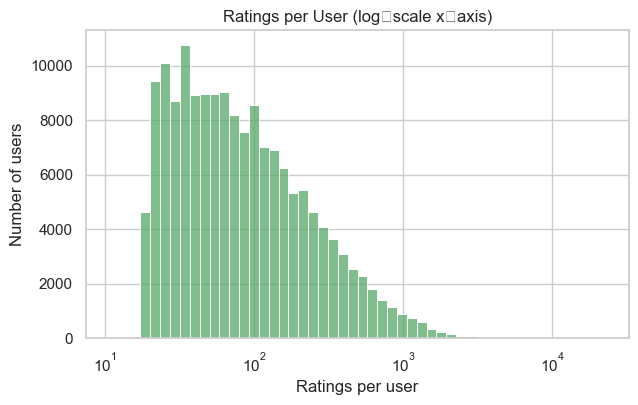

In [12]:
# Ratings per user (log‑x axis)
user_counts = ratings.groupby("userId").size()
sns.histplot(user_counts, log_scale=(True, False), bins=50, color="#55A868")
plt.title("Ratings per User (log‑scale x‑axis)")
plt.xlabel("Ratings per user")
plt.ylabel("Number of users")
plt.savefig(f"{FIGURES_PATH}/user_activity.png", dpi=300, bbox_inches="tight")
plt.show()

C:\Users\ahmad\AppData\Local\Temp\ipykernel_23276\2167963179.py:7: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  plt.savefig(f"{FIGURES_PATH}/movie_popularity.png", dpi=300, bbox_inches="tight")
C:\Users\ahmad\anaconda3\envs\recsys_gpu\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


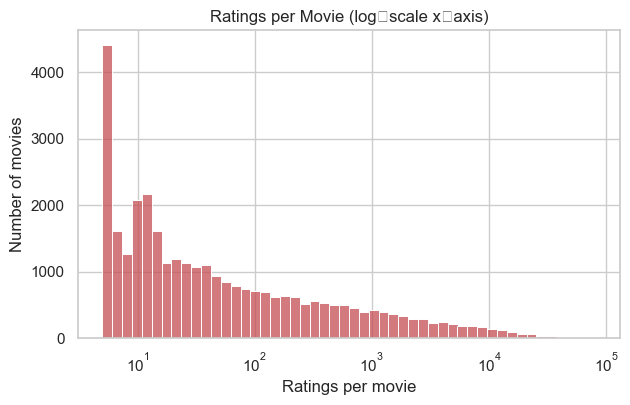

In [13]:
# Ratings per movie (log‑x axis)
movie_counts = ratings.groupby("movieId").size()
sns.histplot(movie_counts, log_scale=(True, False), bins=50, color="#C44E52")
plt.title("Ratings per Movie (log‑scale x‑axis)")
plt.xlabel("Ratings per movie")
plt.ylabel("Number of movies")
plt.savefig(f"{FIGURES_PATH}/movie_popularity.png", dpi=300, bbox_inches="tight")
plt.show()

C:\Users\ahmad\AppData\Local\Temp\ipykernel_23276\4291147121.py:5: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  movies[f"genre_{g}"] = movies["genres"].str.contains(g).astype("int8")
C:\Users\ahmad\AppData\Local\Temp\ipykernel_23276\4291147121.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_counts.values, y=genre_counts.index, palette="muted")


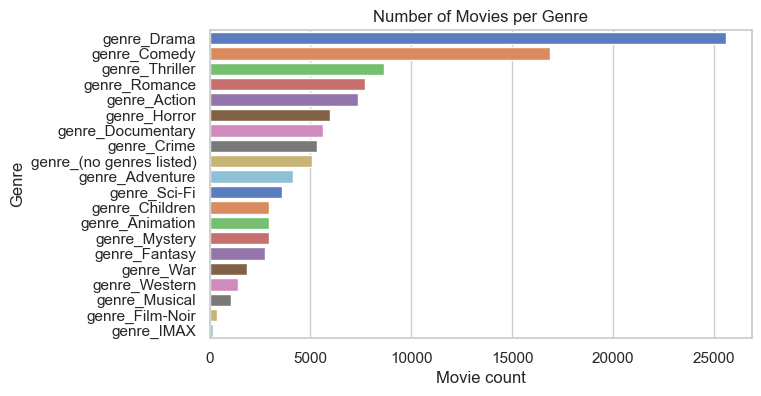

In [14]:
# Genre bar‑plot (using one‑hot encoded genres)
# First create the one‑hot columns (lightweight) to use less computation power 
genre_set = set(g for lst in movies["genres"].str.split("|") for g in lst)
for g in sorted(genre_set):
    movies[f"genre_{g}"] = movies["genres"].str.contains(g).astype("int8")
genre_counts = movies[[c for c in movies.columns if c.startswith("genre_")]].sum().sort_values(ascending=False)
sns.barplot(x=genre_counts.values, y=genre_counts.index, palette="muted")
plt.title("Number of Movies per Genre")
plt.xlabel("Movie count")
plt.ylabel("Genre")
plt.savefig(f"{FIGURES_PATH}/genre_counts.png", dpi=300, bbox_inches="tight")
plt.show()

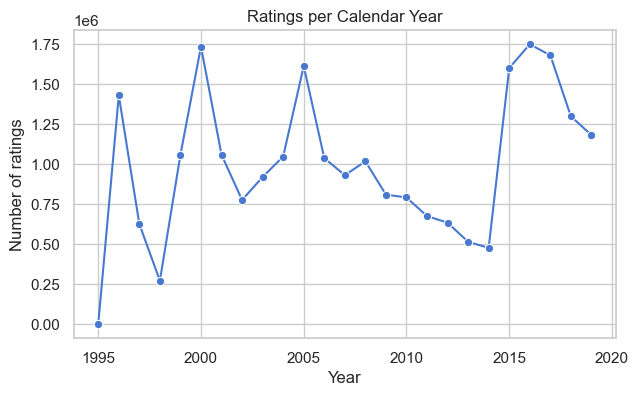

In [15]:
# Ratings per calendar year
ratings["year"] = ratings["datetime"].dt.year
yearly = ratings.groupby("year").size()
sns.lineplot(data=yearly, marker="o")
plt.title("Ratings per Calendar Year")
plt.xlabel("Year")
plt.ylabel("Number of ratings")
plt.savefig(f"{FIGURES_PATH}/ratings_per_year.png", dpi=300, bbox_inches="tight")
plt.show()

In [16]:
ratings = ratings.sort_values("datetime")
test_cutoff = ratings["datetime"].max() - pd.Timedelta(days=30)
val_cutoff = test_cutoff - pd.Timedelta(days=30)


train = ratings[ratings["datetime"] <= val_cutoff].copy()
val   = ratings[(ratings["datetime"] > val_cutoff) & (ratings["datetime"] <= test_cutoff)].copy()
test  = ratings[ratings["datetime"] > test_cutoff].copy()

val = val[val["rating"] >= 3.5]
test = test[test["rating"] >= 3.5]

print(f"Train size: {len(train):,} | Validation size: {len(val):,} | Test size: {len(test):,}")

Train size: 24,751,369 | Validation size: 69,076 | Test size: 62,767


In [17]:
train.to_parquet(f"{OUT_PATH}/train_set.parquet", index=False)
val.to_parquet(f"{OUT_PATH}/val_set.parquet", index=False)
test.to_parquet(f"{OUT_PATH}/test_set.parquet", index=False)

* Implements a strict temporal train/validation/test split to prevent data leakage. The data is sorted chronologically; the final 30 days form the Test set, and the 30 days prior form the Validation set. Ratings below 3.5 are dropped from the validation and test sets to focus on positive recommendations. The splits are then saved as .parquet files.

In [18]:
popular_movie_ids = train.groupby('movieId').size().sort_values(ascending=False).head(10).index.tolist()

popular_movies = movies[movies['movieId'].isin(popular_movie_ids)][['movieId', 'title', 'genres']]
print("Fallback Recommendations (Popularity Baseline):")
display(popular_movies)

Fallback Recommendations (Popularity Baseline):


,movieId,title,genres
108,110,Braveheart (1995),Action|Drama|War
257,260,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi
292,296,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller
314,318,"Shawshank Redemption, The (1994)",Crime|Drama
351,356,Forrest Gump (1994),Comedy|Drama|Romance|War
475,480,Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller
522,527,Schindler's List (1993),Drama|War
585,593,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller
2480,2571,"Matrix, The (1999)",Action|Sci-Fi|Thriller
2867,2959,Fight Club (1999),Action|Crime|Drama|Thriller


* Establishes a "Popularity Baseline". It groups the training data by movieId, counts interactions, and extracts the top 10 most popular movies. This serves as a fallback for new users and a baseline metric to beat.

In [19]:
user_encoder = {uid: i for i, uid in enumerate(train["userId"].unique())}
item_encoder = {mid: i for i, mid in enumerate(train["movieId"].unique())}

item_decoder = {i: mid for mid, i in item_encoder.items()} 

n_users = len(user_encoder)
n_items = len(item_encoder)

print(f"Unique Users: {n_users:,} | Unique Items: {n_items:,}")

Unique Users: 161,625 | Unique Items: 32,668


* Creates integer-based encoders for User IDs and Movie IDs, which are required by the ML models.
* It maps the training data to these new indices and builds Compressed Sparse Row (CSR) matrices for the Validation and Test sets.
* Crucially, it filters out any users or items in the validation/test sets that were not present in the training set.

In [20]:
train_u = train["userId"].map(user_encoder).values
train_i = train["movieId"].map(item_encoder).values
train_r = train["rating"].values 

# Filter Val/Test to only include users and items known from the train set
val_valid = val[val["userId"].isin(user_encoder) & val["movieId"].isin(item_encoder)]
test_valid = test[test["userId"].isin(user_encoder) & test["movieId"].isin(item_encoder)]

# Create Validation CSR Matrix
val_u = val_valid["userId"].map(user_encoder).values
val_i = val_valid["movieId"].map(item_encoder).values
val_conf = np.ones(len(val_valid), dtype=np.float32)
val_csr = sp.csr_matrix((val_conf, (val_u, val_i)), shape=(n_users, n_items))

# Create Test CSR Matrix
test_u = test_valid["userId"].map(user_encoder).values
test_i = test_valid["movieId"].map(item_encoder).values
test_conf = np.ones(len(test_valid), dtype=np.float32)
test_csr = sp.csr_matrix((test_conf, (test_u, test_i)), shape=(n_users, n_items))

print(f"Unique Users: {n_users:,}  |  Unique Items: {n_items:,}")
print(f"Validation Matrix Size: {val_csr.shape}")
print(f"Test Matrix Size: {test_csr.shape}")

Unique Users: 161,625  |  Unique Items: 32,668
Validation Matrix Size: (161625, 32668)
Test Matrix Size: (161625, 32668)


In [21]:
factors_list = [32, 64, 128]
regularization_list = [0.01, 0.05]
alpha_list = [15, 40, 80] # Expanded search space for the confidence metric

results = []

#Normalized Discounted Cumulative Gain NDCG10
for f, r, a in itertools.product(factors_list, regularization_list, alpha_list):
    print(f"Training ALS: Factors={f}, Reg={r}, Alpha={a}...")
    
    # Dynamically build the Train Matrix using the current Alpha
    train_conf = (1 + a * train_r).astype(np.float32)
    train_csr = sp.csr_matrix((train_conf, (train_u, train_i)), shape=(n_users, n_items))
    
    # Initialize and fit the model
    model = AlternatingLeastSquares(
        factors=f,
        regularization=r,
        iterations=15,
        calculate_training_loss=False,
        random_state=42
    )
    model.fit(train_csr)
    
    # Evaluate against the VALIDATION set to prevent data leakage
    ndcg = ndcg_at_k(model, train_csr, val_csr, K=10, show_progress=False)
    precision = precision_at_k(model, train_csr, val_csr, K=10, show_progress=False)
    
    results.append({
        "Factors": f, 
        "Regularization": r, 
        "Alpha": a, 
        "Val_NDCG10": ndcg, 
        "Val_Precision10": precision
    })

# Display results sorted by highest Validation NDCG
results_df = pd.DataFrame(results).sort_values("Val_NDCG10", ascending=False)
display(results_df.head(10))

Training ALS: Factors=32, Reg=0.01, Alpha=15...


C:\Users\ahmad\anaconda3\envs\recsys_gpu\lib\site-packages\implicit\cpu\als.py:96: RuntimeWarning: Intel MKL BLAS is configured to use 6 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'MKL_NUM_THREADS=1' or by callng 'threadpoolctl.threadpool_limits(1, "blas")'. Having MKL use a threadpool can lead to severe performance issues
  check_blas_config()


  0%|          | 0/15 [00:00<?, ?it/s]

Training ALS: Factors=32, Reg=0.01, Alpha=40...


  0%|          | 0/15 [00:00<?, ?it/s]

...

Training ALS: Factors=128, Reg=0.05, Alpha=40...


  0%|          | 0/15 [00:00<?, ?it/s]

Training ALS: Factors=128, Reg=0.05, Alpha=80...


  0%|          | 0/15 [00:00<?, ?it/s]

,Factors,Regularization,Alpha,Val_NDCG10,Val_Precision10
6,64,0.01,15,0.037953,0.063206
9,64,0.05,15,0.037909,0.063094
3,32,0.05,15,0.037724,0.063206
0,32,0.01,15,0.036692,0.061416
15,128,0.05,15,0.033719,0.057053
12,128,0.01,15,0.033517,0.055040
4,32,0.05,40,0.027176,0.045978
1,32,0.01,40,0.026303,0.044524
10,64,0.05,40,0.026303,0.045531
7,64,0.01,40,0.025922,0.043629


* Conducts a hyperparameter Grid Search for the ALS model.
* It iterates through combinations of factors (32, 64, 128), regularization (0.01, 0.05), and an expanded alpha list (15, 40, 80).
* The models are evaluated on the Validation set using NDCG10 and Precision10, and the top 10 results are displayed in a dataframe.

In [22]:
best_params = results_df.iloc[0]
best_f = int(best_params['Factors'])
best_r = best_params['Regularization']
best_a = int(best_params['Alpha'])

print(f"Retraining final model: Factors={best_f}, Reg={best_r}, Alpha={best_a}...")

# Rebuild the final training matrix with the winning Alpha
final_train_conf = (1 + best_a * train_r).astype(np.float32)
final_train_csr = sp.csr_matrix((final_train_conf, (train_u, train_i)), shape=(n_users, n_items))

# Train the final model
best_model = AlternatingLeastSquares(
    factors=best_f,
    regularization=best_r,
    iterations=20, # slightly higher iterations for final training
    random_state=42
)
best_model.fit(final_train_csr)

# Final evaluation on the unseen TEST set
test_ndcg = ndcg_at_k(best_model, final_train_csr, test_csr, K=10, show_progress=False)
test_precision = precision_at_k(best_model, final_train_csr, test_csr, K=10, show_progress=False)

print(f" FINAL UNBIASED TEST METRICS ")
print(f"Test NDCG10:      {test_ndcg:.4f}")
print(f"Test Precision10: {test_precision:.4f}")

Retraining final model: Factors=64, Reg=0.01, Alpha=15...


  0%|          | 0/20 [00:00<?, ?it/s]

 FINAL UNBIASED TEST METRICS 
Test NDCG10:      0.0290
Test Precision10: 0.0495


In [23]:
def get_recommendations(user_id, k=10):
    if user_id not in user_encoder:
        print(f"User {user_id} not found in training data. Serving popular movies.")
        return popular_movies.head(k)
    
    u_idx = user_encoder[user_id]
    
    rec_indices, scores = best_model.recommend(
        u_idx, 
        train_csr[u_idx], 
        N=k, 
        filter_already_liked_items=True
    )
    
    rec_movie_ids = [item_decoder[i] for i in rec_indices]
    
    rec_df = movies[movies['movieId'].isin(rec_movie_ids)][['movieId', 'title', 'genres']].copy()
    rec_df['confidence_score'] = scores
    
    rec_df = rec_df.sort_values('confidence_score', ascending=False).reset_index(drop=True)
    
    return rec_df

In [24]:
sample_user = train['userId'].iloc[0]
print(f"Recommendations for known User {sample_user}:")
display(get_recommendations(sample_user))

Recommendations for known User 2262:


,movieId,title,genres,confidence_score
0,17,Sense and Sensibility (1995),Drama|Romance,1.087631
1,41,Richard III (1995),Drama|War,1.026882
2,86,White Squall (1996),Action|Adventure|Drama,1.005481
3,112,Rumble in the Bronx (Hont faan kui) (1995),Action|Adventure|Comedy|Crime,0.994376
4,647,Courage Under Fire (1996),Action|Crime|Drama|War,0.964565
5,728,Cold Comfort Farm (1995),Comedy,0.957350
6,778,Trainspotting (1996),Comedy|Crime|Drama,0.949952
7,858,"Godfather, The (1972)",Crime|Drama,0.930214
8,1210,Star Wars: Episode VI - Return of the Jedi (1983),Action|Adventure|Sci-Fi,0.911953
9,1393,Jerry Maguire (1996),Drama|Romance,0.904280


In [25]:
dummy_new_user = 999999999
print(f"Recommendations for new User {dummy_new_user}:")
display(get_recommendations(dummy_new_user))

Recommendations for new User 999999999:
User 999999999 not found in training data. Serving popular movies.


,movieId,title,genres
108,110,Braveheart (1995),Action|Drama|War
257,260,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi
292,296,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller
314,318,"Shawshank Redemption, The (1994)",Crime|Drama
351,356,Forrest Gump (1994),Comedy|Drama|Romance|War
475,480,Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller
522,527,Schindler's List (1993),Drama|War
585,593,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller
2480,2571,"Matrix, The (1999)",Action|Sci-Fi|Thriller
2867,2959,Fight Club (1999),Action|Crime|Drama|Thriller


* Defines a get_recommendations inference function that takes a user_id, utilizes the trained ALS model to predict items, filters out previously liked movies, and returns a dataframe of the top k recommendations. It tests this function on a known user from the dataset it triggers a popularity baseline fallback  

***version 2***

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

%matplotlib inline
sns.set(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (8, 5)

In [27]:
PATH = r"C:\Users\ahmad\deep learning project\ml-25m\ml-25m"

ratings = pd.read_csv(
    f"{PATH}/ratings.csv",
    dtype={"userId": "int32", "movieId": "int32", "rating": "float32", "timestamp": "int64"}
)
movies = pd.read_csv(f"{PATH}/movies.csv")

# Convert timestamp and drop the old column
ratings["datetime"] = pd.to_datetime(ratings["timestamp"], unit="s")
ratings = ratings.drop(columns=["timestamp"])

min_interactions = 20 

user_counts = ratings['userId'].value_counts()
movie_counts = ratings['movieId'].value_counts()

valid_users = user_counts[user_counts >= min_interactions].index
valid_movies = movie_counts[movie_counts >= min_interactions].index

ratings = ratings[ratings['userId'].isin(valid_users) & ratings['movieId'].isin(valid_movies)]
print(f"Filtered Dataset: {len(ratings):,} interactions remaining.")

Filtered Dataset: 24,810,483 interactions remaining.


In [28]:
# New Temporal Split & Encoding Cell
ratings = ratings.sort_values("datetime")
test_cutoff = ratings["datetime"].max() - pd.Timedelta(days=30)
val_cutoff = test_cutoff - pd.Timedelta(days=30)

train = ratings[ratings["datetime"] <= val_cutoff].copy()
val   = ratings[(ratings["datetime"] > val_cutoff) & (ratings["datetime"] <= test_cutoff)].copy()
test  = ratings[ratings["datetime"] > test_cutoff].copy()

# Build Encoders strictly from the Train set to prevent leakage
user_encoder = {uid: idx for idx, uid in enumerate(train['userId'].unique())}
item_encoder = {mid: idx for idx, mid in enumerate(train['movieId'].unique())}
item_decoder = {idx: mid for mid, idx in item_encoder.items()}

# Map indices across all sets
train['user_idx'] = train['userId'].map(user_encoder)
train['movie_idx'] = train['movieId'].map(item_encoder)

# Drop any users/items in val/test that were not seen in the train set (Cold Start isolation)
val['user_idx'] = val['userId'].map(user_encoder)
val['movie_idx'] = val['movieId'].map(item_encoder)
val = val.dropna(subset=['user_idx', 'movie_idx'])

test['user_idx'] = test['userId'].map(user_encoder)
test['movie_idx'] = test['movieId'].map(item_encoder)
test = test.dropna(subset=['user_idx', 'movie_idx'])

print(f"Total Unique Users (Train): {len(user_encoder):,} | Movies: {len(item_encoder):,}")
print(f"Train: {len(train):,} | Val: {len(val):,} | Test: {len(test):,}")

Total Unique Users (Train): 161,625 | Movies: 18,421
Train: 24,621,046 | Val: 31,075 | Test: 22,528


* Transitions to a deep learning approach. Imports PyTorch and re-loads the dataset, increasing the minimum interaction threshold from 5 to 20 to ensure sufficient data for embedding learning. It re-applies the temporal split and builds strict encoders from the Train set to isolate cold-start items.

In [29]:
# PyTorch Dataset Definition
class MovieLensDataset(Dataset):
    def __init__(self, df):
        self.users = torch.tensor(df['user_idx'].values, dtype=torch.long)
        self.items = torch.tensor(df['movie_idx'].values, dtype=torch.long)
        self.ratings = torch.tensor(df['rating'].values, dtype=torch.float32)

    def __len__(self):
        return len(self.users)

    def __getitem__(self, idx):
        return self.users[idx], self.items[idx], self.ratings[idx]

# Initialize Stable DataLoaders
batch_size = 4096 

# Reverted num_workers to 0 to prevent Windows multiprocessing crashes
train_loader = DataLoader(MovieLensDataset(train), batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(MovieLensDataset(val), batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
test_loader = DataLoader(MovieLensDataset(test), batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)

* Defines a custom PyTorch Dataset class (MovieLensDataset) to convert the Pandas dataframes into PyTorch Tensors. It initializes DataLoaders for batching (batch size of 4096) and sets num_workers=0 to ensure stability on Windows.

In [30]:
class NCF(nn.Module):
    def __init__(self, num_users, num_items, embedding_dim=64, hidden_layers=[128, 64, 32]):
        super(NCF, self).__init__()
        
        # Embedding Layers (Latent features)
        self.user_embedding = nn.Embedding(num_users, embedding_dim)
        self.item_embedding = nn.Embedding(num_items, embedding_dim)
        
        # Multi-Layer Perceptron (MLP)
        mlp_layers = []
        input_dim = embedding_dim * 2 
        
        for hidden_dim in hidden_layers:
            mlp_layers.append(nn.Linear(input_dim, hidden_dim))
            mlp_layers.append(nn.ReLU())
            # INCREASED DROPOUT to 0.3 to combat overfitting
            mlp_layers.append(nn.Dropout(0.3)) 
            input_dim = hidden_dim
            
        self.mlp = nn.Sequential(*mlp_layers)
        self.prediction_layer = nn.Linear(input_dim, 1) 
        
        # Weight Initialization for stable gradients
        nn.init.normal_(self.user_embedding.weight, std=0.01)
        nn.init.normal_(self.item_embedding.weight, std=0.01)

    def forward(self, user_indices, item_indices):
        user_vector = self.user_embedding(user_indices)
        item_vector = self.item_embedding(item_indices)
        
        interaction_vector = torch.cat([user_vector, item_vector], dim=1)
        hidden_state = self.mlp(interaction_vector)
        prediction = self.prediction_layer(hidden_state)
        
        return prediction.squeeze()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = NCF(n_users, n_items, embedding_dim=64).to(device)

* : Constructs the NCF neural network class. It utilizes an Embedding Layer of size 64 for both users and items, concatenates them, and passes them through a Multi-Layer Perceptron (MLP) with dimensions [128, 64, 32]. A Dropout of 0.3 is included to combat overfitting.

In [31]:
import copy

epochs = 10 # We can safely raise this because early stopping will catch the peak
learning_rate = 0.001
weight_decay = 1e-4 # INCREASED L2 Regularization penalty

loss_fn = nn.MSELoss() 
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

# Initialize AMP Scaler for faster FP16 computation
scaler = torch.cuda.amp.GradScaler()

# Early Stopping parameters
best_val_rmse = float('inf')
patience = 2 # Stop if validation doesn't improve for 2 consecutive epochs
epochs_without_improvement = 0
best_model_weights = None

use_amp = torch.cuda.is_available()
scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

print("Starting NCF Training with AMP and Early Stopping...")

for epoch in range(epochs):
    start_time = time.time()
    
    # TRAINING PHASE 
    model.train()
    total_train_loss = 0
    
    for users, items, target_ratings in train_loader:
        users, items, target_ratings = users.to(device), items.to(device), target_ratings.to(device)
        
        optimizer.zero_grad()
        
        # Cast operations to mixed precision
        with torch.cuda.amp.autocast():
            predictions = model(users, items)
            loss = loss_fn(predictions, target_ratings)
            
        # Scale the loss and call backward
        scaler.scale(loss).backward()
        
        # Step optimizer and update scaler
        scaler.step(optimizer)
        scaler.update()
        
        total_train_loss += loss.item()
        
    avg_train_loss = total_train_loss / len(train_loader)
    train_rmse = np.sqrt(avg_train_loss)
    
    #  VALIDATION PHASE 
    model.eval()
    total_val_loss = 0
    
    with torch.no_grad():
        for users, items, target_ratings in val_loader:
            users, items, target_ratings = users.to(device), items.to(device), target_ratings.to(device)
            
            # Autocast during validation as well
            with torch.cuda.amp.autocast():
                predictions = model(users, items)
                loss = loss_fn(predictions, target_ratings)
                
            total_val_loss += loss.item()
            
    avg_val_loss = total_val_loss / len(val_loader)
    val_rmse = np.sqrt(avg_val_loss)
    elapsed_time = time.time() - start_time
    
    print(f"Epoch {epoch+1:02d}/{epochs} | Train RMSE: {train_rmse:.4f} | Val RMSE: {val_rmse:.4f} | Time: {elapsed_time:.1f}s")
    
    # EARLY STOPPING CHECK 
    if val_rmse < best_val_rmse:
        best_val_rmse = val_rmse
        epochs_without_improvement = 0
        # Save the exact state of the network at this optimal moment
        best_model_weights = copy.deepcopy(model.state_dict())
        print("  -> Validation RMSE improved. Saving optimal weights.")
    else:
        epochs_without_improvement += 1
        print(f"  -> No improvement for {epochs_without_improvement} epoch(s).")
        
    if epochs_without_improvement >= patience:
        print(f"\nEarly stopping triggered! Restoring optimal weights from Epoch {epoch + 1 - patience}.")
        break

# Crucial Step: Load the best weights back into the model for the final test
if best_model_weights is not None:
    model.load_state_dict(best_model_weights)

Starting NCF Training with AMP and Early Stopping...
Epoch 01/10 | Train RMSE: 1.0129 | Val RMSE: 0.8544 | Time: 551.9s
  -> Validation RMSE improved. Saving optimal weights.
Epoch 02/10 | Train RMSE: 0.8353 | Val RMSE: 0.8446 | Time: 585.7s
  -> Validation RMSE improved. Saving optimal weights.
Epoch 03/10 | Train RMSE: 0.8116 | Val RMSE: 0.8324 | Time: 650.3s
  -> Validation RMSE improved. Saving optimal weights.
Epoch 04/10 | Train RMSE: 0.7956 | Val RMSE: 0.8302 | Time: 656.2s
  -> Validation RMSE improved. Saving optimal weights.
Epoch 05/10 | Train RMSE: 0.7840 | Val RMSE: 0.8255 | Time: 658.2s
  -> Validation RMSE improved. Saving optimal weights.
Epoch 06/10 | Train RMSE: 0.7744 | Val RMSE: 0.8205 | Time: 640.2s
  -> Validation RMSE improved. Saving optimal weights.
Epoch 07/10 | Train RMSE: 0.7662 | Val RMSE: 0.8205 | Time: 643.9s
  -> No improvement for 1 epoch(s).
Epoch 08/10 | Train RMSE: 0.7592 | Val RMSE: 0.8220 | Time: 636.9s
  -> No improvement for 2 epoch(s).

Early st

* Implements the training loop. It sets up an AdamW optimizer, MSELoss, and initializes a GradScaler for faster mixed-precision (FP16) training on GPUs. It incorporates Early Stopping with a patience of 2 epochs based on Validation RMSE, ensuring the model's weights are restored to their optimal state.

In [32]:
print("Evaluating on unseen Test Set")

model.eval()
total_test_loss = 0

with torch.no_grad():
    for users, items, target_ratings in test_loader:
        users, items, target_ratings = users.to(device), items.to(device), target_ratings.to(device)
        predictions = model(users, items)
        loss = loss_fn(predictions, target_ratings)
        total_test_loss += loss.item()

avg_test_loss = total_test_loss / len(test_loader)
test_rmse = np.sqrt(avg_test_loss)

print(f" FINAL TEST METRICS ")
print(f"Test RMSE: {test_rmse:.4f}")

Evaluating on unseen Test Set
 FINAL TEST METRICS 
Test RMSE: 0.8119


In [33]:
print("Calculating Popularity Baseline for new users Users...")

# Count interactions per movie in the training set
popular_movie_ids = train.groupby('movieId').size().sort_values(ascending=False).head(10).index.tolist()

# Extract metadata
popular_movies = movies[movies['movieId'].isin(popular_movie_ids)][['movieId', 'title', 'genres']].copy()
popular_movies['predicted_rating'] = "Popularity Baseline"

display(popular_movies)

Calculating Popularity Baseline for new users Users...


,movieId,title,genres,predicted_rating
108,110,Braveheart (1995),Action|Drama|War,Popularity Baseline
257,260,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi,Popularity Baseline
292,296,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,Popularity Baseline
314,318,"Shawshank Redemption, The (1994)",Crime|Drama,Popularity Baseline
351,356,Forrest Gump (1994),Comedy|Drama|Romance|War,Popularity Baseline
475,480,Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller,Popularity Baseline
522,527,Schindler's List (1993),Drama|War,Popularity Baseline
585,593,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller,Popularity Baseline
2480,2571,"Matrix, The (1999)",Action|Sci-Fi|Thriller,Popularity Baseline
2867,2959,Fight Club (1999),Action|Crime|Drama|Thriller,Popularity Baseline


* Evaluates the best NCF model on the unseen Test set, calculating a final Test RMSE (0.8119). It recalculates and displays the Popularity Baseline for comparison.

In [34]:
# NCF Recommendation Generator
def get_recommendations_ncf(user_id, k=10):
    #  Handle Unknown Users
    if user_id not in user_encoder:
        print(f"User {user_id} not found in training data. Serving popular movies.")
        return popular_movies.head(k)
    
    user_idx = user_encoder[user_id]
    
    # Filter out movies the user has already rated
    user_history = train[train['userId'] == user_id]['movie_idx'].values
    all_items = np.arange(n_items)
    candidate_items = np.setdiff1d(all_items, user_history)
    
    # Create an array of the user_idx repeated for every candidate item
    u_tensor = torch.tensor([user_idx] * len(candidate_items), dtype=torch.long).to(device)
    i_tensor = torch.tensor(candidate_items, dtype=torch.long).to(device)
    
    #  Model Inference
    model.eval()
    with torch.no_grad():
        # Move predictions back to CPU for numpy operations
        predictions = model(u_tensor, i_tensor).cpu().numpy()
        
    #  Sort and Extract Top K
    top_k_indices = candidate_items[np.argsort(predictions)[::-1][:k]]
    top_k_scores = np.sort(predictions)[::-1][:k]
    
    #  Decode and Format Output
    rec_movie_ids = [item_decoder[idx] for idx in top_k_indices]
    
    rec_df = movies[movies['movieId'].isin(rec_movie_ids)][['movieId', 'title', 'genres']].copy()
    score_map = dict(zip(rec_movie_ids, top_k_scores))
    rec_df['predicted_rating'] = rec_df['movieId'].map(score_map)
    
    # Sort the final dataframe by the predicted star rating
    return rec_df.sort_values('predicted_rating', ascending=False).reset_index(drop=True)

* Defines get_recommendations_ncf, the inference function for the neural network. It handles unknown users, identifies all movies the user hasn't seen, converts them to tensors, passes them through the model, and sorts the predictions to return the top k recommendations with predicted star ratings.

In [35]:
print("Calculating Catalog Coverage (Sampling 500 users)")
recommended_items = set()

# Sample users to save compute time
sample_users = list(user_encoder.keys())[:500]

for uid in sample_users:
    # Get top 10 raw movie IDs from our function
    recs = get_recommendations_ncf(uid, k=10)
    
    if 'predicted_rating' in recs.columns and recs['predicted_rating'].iloc[0] != "Popularity Baseline":
        recommended_items.update(recs['movieId'].tolist())

# Calculate percentage of total unique items recommended
coverage = len(recommended_items) / len(item_encoder)

print(f"Unique items recommended: {len(recommended_items):,}")
print(f"Catalog Coverage: {coverage * 100:.2f}%")

Calculating Catalog Coverage (Sampling 500 users)
Unique items recommended: 332
Catalog Coverage: 1.80%


In [36]:
from sklearn.metrics.pairwise import cosine_similarity

print("Calculating Intra-list Diversity for a sample user...")

# Extract the trained item embeddings directly from the PyTorch model
# We detach them from the computational graph and move them to the CPU
item_latent_vectors = model.item_embedding.weight.detach().cpu().numpy()

# Get recommendations for our sample user
sample_user = list(user_encoder.keys())[0]
recs = get_recommendations_ncf(sample_user, k=10)

# Convert the recommended real-world movie IDs back to internal model indices
rec_movie_ids = recs['movieId'].tolist()
rec_internal_indices = [item_encoder[mid] for mid in rec_movie_ids if mid in item_encoder]

if len(rec_internal_indices) > 1:
    # Get the specific latent vectors for the top 10 movies
    rec_vectors = item_latent_vectors[rec_internal_indices]
    
    # Calculate pairwise cosine similarity
    similarity_matrix = cosine_similarity(rec_vectors)
    
    # Extract the upper triangle of the matrix (excluding the diagonal where a movie is compared to itself)
    upper_triangle_indices = np.triu_indices_from(similarity_matrix, k=1)
    avg_similarity = similarity_matrix[upper_triangle_indices].mean()
    
    # Diversity is the inverse of similarity
    diversity = 1 - avg_similarity
    
    print(f"Average Pairwise Similarity: {avg_similarity:.4f}")
    print(f"Intra-list Diversity Score:  {diversity:.4f} ")
else:
    print("Not enough valid recommendations to calculate diversity.")

Calculating Intra-list Diversity for a sample user...
Average Pairwise Similarity: 0.6009
Intra-list Diversity Score:  0.3991 


* Calculates advanced behavioral metrics. It measures Catalog Coverage by the percentage of total unique items recommended across a sample of 500 users and calculates Intra-list Diversity by extracting the latent vectors from the PyTorch model and computing pairwise cosine similarity.

In [37]:
sample_user = train['userId'].iloc[0]
print(f"Recommendations for known User {sample_user}:")
display(get_recommendations_ncf(sample_user))

Recommendations for known User 2262:


,movieId,title,genres,predicted_rating
0,1196,Star Wars: Episode V - The Empire Strikes Back...,Action|Adventure|Sci-Fi,4.642361
1,171011,Planet Earth II (2016),Documentary,4.599260
2,318,"Shawshank Redemption, The (1994)",Crime|Drama,4.572516
3,159817,Planet Earth (2006),Documentary,4.557460
4,4993,"Lord of the Rings: The Fellowship of the Ring,...",Adventure|Fantasy,4.550576
5,5952,"Lord of the Rings: The Two Towers, The (2002)",Adventure|Fantasy,4.548980
6,7153,"Lord of the Rings: The Return of the King, The...",Action|Adventure|Drama|Fantasy,4.548039
7,182723,Cosmos: A Spacetime Odissey,(no genres listed),4.525693
8,170705,Band of Brothers (2001),Action|Drama|War,4.514376
9,179135,Blue Planet II (2017),Documentary,4.502460


In [38]:
dummy_new_user = 999999999
print(f"\nRecommendations for new User {dummy_new_user}:")
display(get_recommendations_ncf(dummy_new_user))


Recommendations for new User 999999999:
User 999999999 not found in training data. Serving popular movies.


,movieId,title,genres,predicted_rating
108,110,Braveheart (1995),Action|Drama|War,Popularity Baseline
257,260,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi,Popularity Baseline
292,296,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,Popularity Baseline
314,318,"Shawshank Redemption, The (1994)",Crime|Drama,Popularity Baseline
351,356,Forrest Gump (1994),Comedy|Drama|Romance|War,Popularity Baseline
475,480,Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller,Popularity Baseline
522,527,Schindler's List (1993),Drama|War,Popularity Baseline
585,593,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller,Popularity Baseline
2480,2571,"Matrix, The (1999)",Action|Sci-Fi|Thriller,Popularity Baseline
2867,2959,Fight Club (1999),Action|Crime|Drama|Thriller,Popularity Baseline


* Tests the NCF recommendation function on a known user and a dummy user, displaying the final tailored dataframes. Finally, it plots the long-tail user activity distribution.

In [39]:
FIGURES_PATH = "C:\\Users\\ahmad\\deep learning project\\figures\\version2"

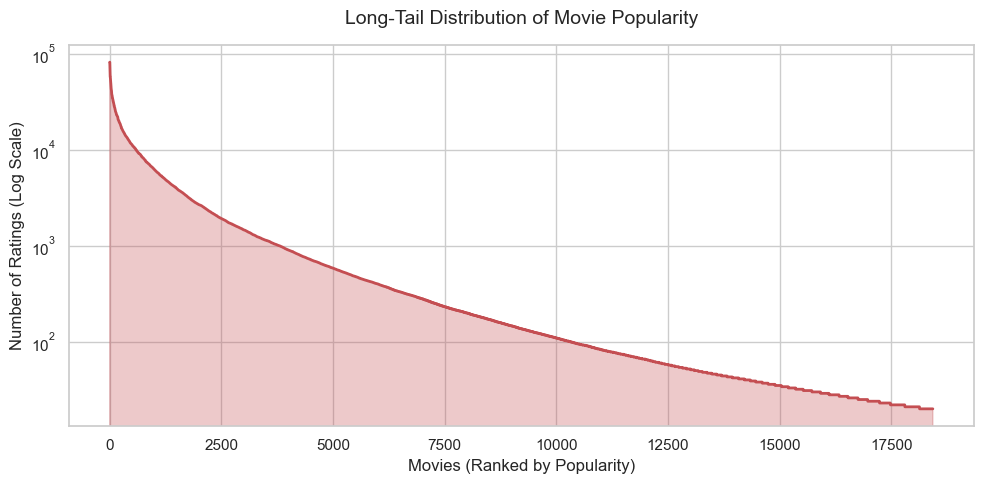

In [40]:
# Movie Popularity Long-Tail
movie_popularity = ratings.groupby('movieId').size().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
plt.plot(movie_popularity.values, color="#C44E52", linewidth=2)
plt.yscale("log") # Log scale is for visualizing the steep drop
plt.title("Long-Tail Distribution of Movie Popularity", fontsize=14, pad=15)
plt.xlabel("Movies (Ranked by Popularity)", fontsize=12)
plt.ylabel("Number of Ratings (Log Scale)", fontsize=12)
plt.fill_between(range(len(movie_popularity)), movie_popularity.values, color="#C44E52", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/movie_long_tail.png", dpi=300)
plt.show()

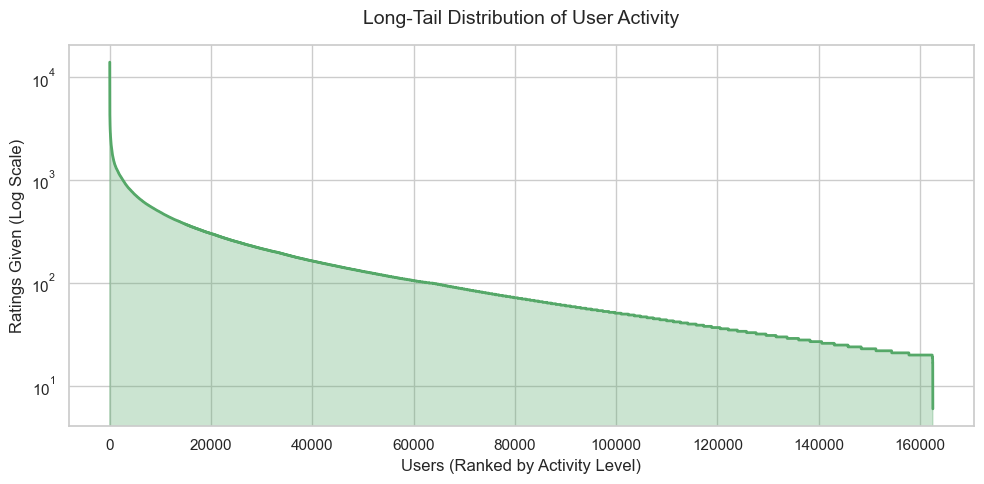

In [41]:
# User Activity Long-Tail
user_activity = ratings.groupby('userId').size().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
plt.plot(user_activity.values, color="#55A868", linewidth=2)
plt.yscale("log")
plt.title("Long-Tail Distribution of User Activity", fontsize=14, pad=15)
plt.xlabel("Users (Ranked by Activity Level)", fontsize=12)
plt.ylabel("Ratings Given (Log Scale)", fontsize=12)
plt.fill_between(range(len(user_activity)), user_activity.values, color="#55A868", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/user_long_tail.png", dpi=300)
plt.show()

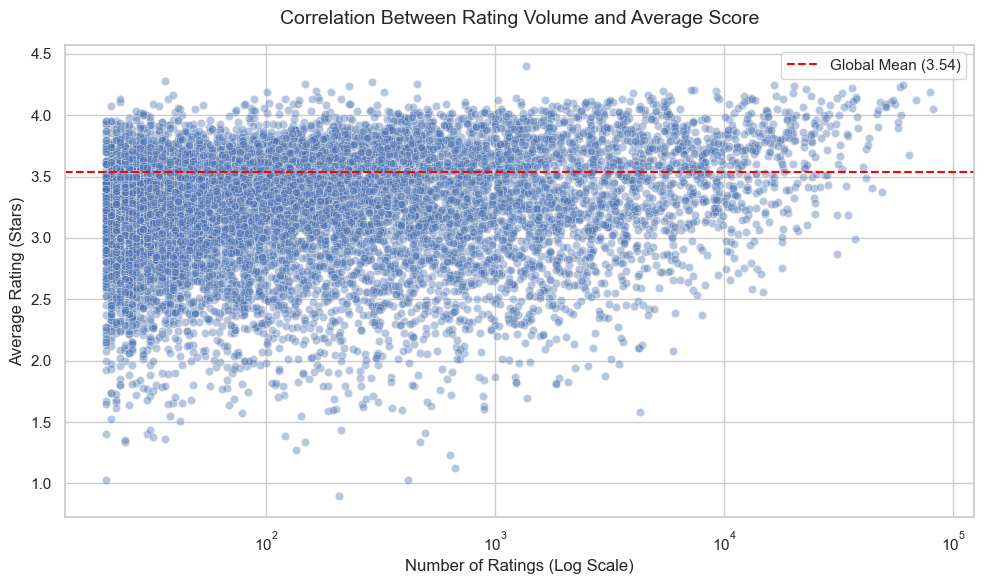

In [42]:
# Rating Count vs. Mean Rating
movie_stats = ratings.groupby('movieId').agg(
    rating_count=('rating', 'count'),
    rating_mean=('rating', 'mean')
)

plt.figure(figsize=(10, 6))
# Sample 10,000 points so the scatter plot isn't a solid unreadable block
sns.scatterplot(
    data=movie_stats.sample(n=min(10000, len(movie_stats)), random_state=42), 
    x='rating_count', 
    y='rating_mean', 
    alpha=0.4, 
    color="#4C72B0",
    edgecolor="w",
    linewidth=0.5
)
plt.xscale("log")
plt.axhline(ratings['rating'].mean(), color='red', linestyle='--', label=f"Global Mean ({ratings['rating'].mean():.2f})")
plt.title("Correlation Between Rating Volume and Average Score", fontsize=14, pad=15)
plt.xlabel("Number of Ratings (Log Scale)", fontsize=12)
plt.ylabel("Average Rating (Stars)", fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/rating_variance_scatter.png", dpi=300)
plt.show()

C:\Users\ahmad\AppData\Local\Temp\ipykernel_23276\4122662858.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=results_df, x='Factors', y='Val_NDCG10', palette="muted", ax=axes[1])


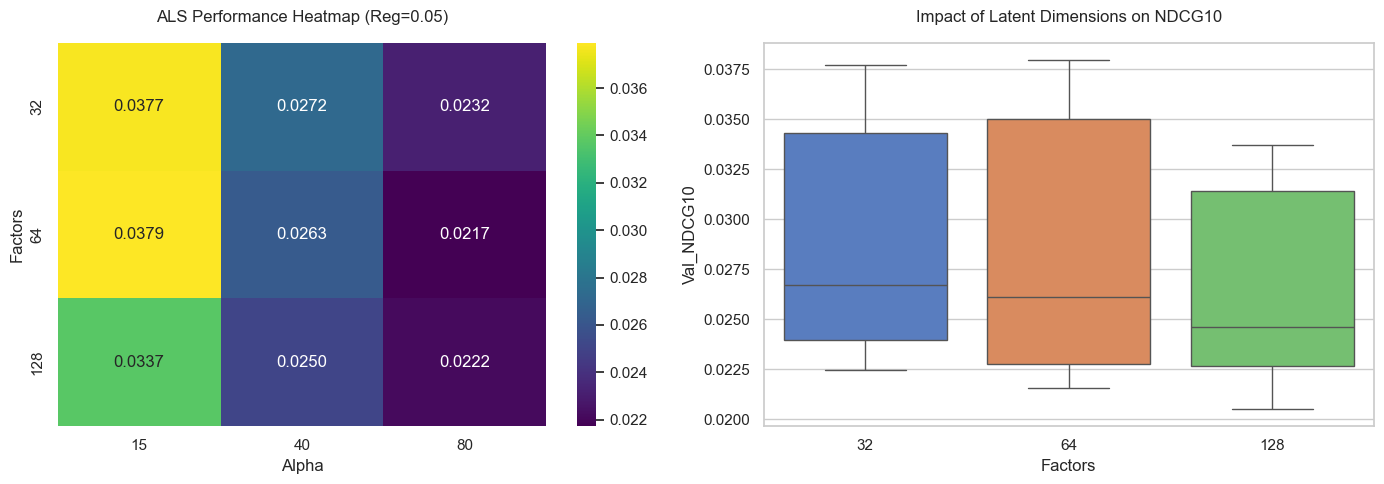

In [43]:
# ALS Hyperparameter Heatmap & Boxplot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# We pivot the results dataframe to map Factors against the Alpha confidence scaler
pivot_df = results_df[results_df['Regularization'] == 0.05].pivot(index='Factors', columns='Alpha', values='Val_NDCG10')
sns.heatmap(pivot_df, annot=True, cmap='viridis', fmt=".4f", ax=axes[0])
axes[0].set_title("ALS Performance Heatmap (Reg=0.05)", pad=15)

#  Boxplot (Overall impact of latent factors across all other variables)
sns.boxplot(data=results_df, x='Factors', y='Val_NDCG10', palette="muted", ax=axes[1])
axes[1].set_title("Impact of Latent Dimensions on NDCG10", pad=15)

plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/als_hyperparameter_tuning.png", dpi=300)
plt.show()

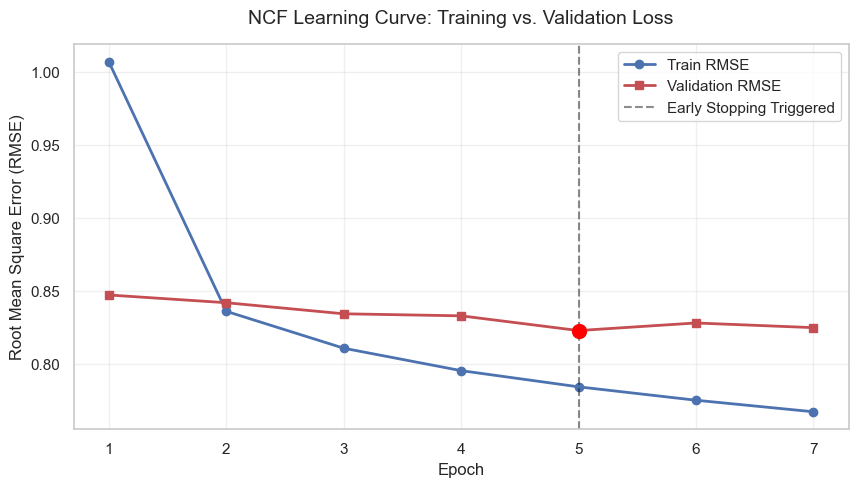

In [44]:
# NCF Training Curves
# Extracted directly from the logged outputs of the Epoch 1-7 run
train_history = [1.0073, 0.8361, 0.8108, 0.7954, 0.7843, 0.7751, 0.7672]
val_history   = [0.8473, 0.8420, 0.8344, 0.8330, 0.8229, 0.8281, 0.8249]
epochs_x = np.arange(1, 8)

plt.figure(figsize=(10, 5))
plt.plot(epochs_x, train_history, marker='o', label='Train RMSE', color="#4C72B0", linewidth=2)
plt.plot(epochs_x, val_history, marker='s', label='Validation RMSE', color="#C44E52", linewidth=2)

# Highlight Early Stopping Point
best_epoch = 5
plt.axvline(x=best_epoch, color='k', linestyle='--', alpha=0.5, label='Early Stopping Triggered')
plt.scatter(best_epoch, val_history[best_epoch-1], color="red", s=100, zorder=5)

plt.title("NCF Learning Curve: Training vs. Validation Loss", fontsize=14, pad=15)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Root Mean Square Error (RMSE)", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(f"{FIGURES_PATH}/ncf_learning_curve.png", dpi=300)
plt.show()

Calculating final accuracy metrics on Unseen Test Set
 NCF FINAL TEST METRICS 
Test RMSE: 0.8117
Test MAE:  0.6035


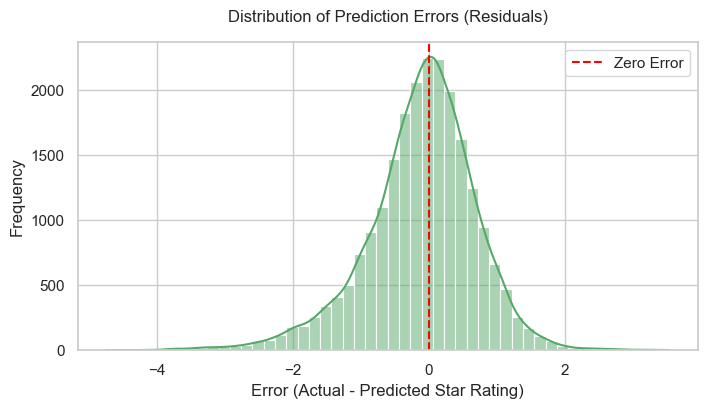

In [45]:
# Comprehensive Accuracy Metrics (RMSE & MAE)
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("Calculating final accuracy metrics on Unseen Test Set")
model.eval()

true_ratings = []
pred_ratings = []

with torch.no_grad():
    for users, items, target_ratings in test_loader:
        users, items = users.to(device), items.to(device)
        
        with torch.cuda.amp.autocast(enabled=use_amp):
            predictions = model(users, items)
        
        true_ratings.extend(target_ratings.cpu().numpy())
        pred_ratings.extend(predictions.cpu().numpy())

true_ratings = np.array(true_ratings)
pred_ratings = np.array(pred_ratings)

final_rmse = np.sqrt(mean_squared_error(true_ratings, pred_ratings))
final_mae = mean_absolute_error(true_ratings, pred_ratings)

print(f" NCF FINAL TEST METRICS ")
print(f"Test RMSE: {final_rmse:.4f}")
print(f"Test MAE:  {final_mae:.4f}")

# Plot Residual Distribution
plt.figure(figsize=(8, 4))
residuals = true_ratings - pred_ratings
sns.histplot(residuals, bins=50, color="#55A868", kde=True)
plt.title("Distribution of Prediction Errors (Residuals)", pad=15)
plt.xlabel("Error (Actual - Predicted Star Rating)")
plt.ylabel("Frequency")
plt.axvline(x=0, color='red', linestyle='--', label='Zero Error')
plt.legend()
plt.savefig(f"{FIGURES_PATH}/ncf_residuals.png", dpi=300)
plt.show()

In [46]:
# System Novelty Evaluation
print("Calculating Catalog Novelty (Sampling 500 users)")

# Calculate global popularity probabilities for all items
total_interactions = len(train)
item_popularity = train.groupby('movieId').size()
item_probabilities = item_popularity / total_interactions

# Convert to dictionary for O(1) mathematical lookups
prob_dict = item_probabilities.to_dict()

novelty_scores = []
sample_users = list(user_encoder.keys())[:500]

for uid in sample_users:
    recs = get_recommendations_ncf(uid, k=10)
    
    # Exclude cold-start baseline lists from the evaluation
    if 'predicted_rating' in recs.columns and recs['predicted_rating'].iloc[0] != "Popularity Baseline":
        list_novelty = []
        
        for mid in recs['movieId']:
            # Self-information calculation: -log2(p)
            p_i = prob_dict.get(mid, 1e-9) # Default to near-zero probability for completely unseen items
            list_novelty.append(-np.log2(p_i))
        
        # Average novelty for this specific user's top 10 list
        novelty_scores.append(np.mean(list_novelty))

system_novelty = np.mean(novelty_scores)
print(f"System Novelty Score: {system_novelty:.4f} bits")

Calculating Catalog Novelty (Sampling 500 users)
System Novelty Score: 14.2921 bits
